In [1]:
# Import important library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn import model_selection
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc, roc_curve, classification_report, roc_auc_score
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### Read the input file and check the data dimension

In [2]:
# reading the CSV file into pandas dataframe
df = pd.read_csv("german_credit.csv") 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
default                       1000 non-null int64
account_check_status          1000 non-null object
duration_in_month             1000 non-null int64
credit_history                1000 non-null object
purpose                       1000 non-null object
credit_amount                 1000 non-null int64
savings                       1000 non-null object
present_emp_since             1000 non-null object
installment_as_income_perc    1000 non-null int64
personal_status_sex           1000 non-null object
other_debtors                 1000 non-null object
present_res_since             1000 non-null int64
property                      1000 non-null object
age                           1000 non-null int64
other_installment_plans       1000 non-null object
housing                       1000 non-null object
credits_this_bank             1000 non-null int64
job                           1000

In [3]:
df.head()

,default,account_check_status,duration_in_month,credit_history,purpose,credit_amount,savings,present_emp_since,installment_as_income_perc,personal_status_sex,...,present_res_since,property,age,other_installment_plans,housing,credits_this_bank,job,people_under_maintenance,telephone,foreign_worker
0,0,< 0 DM,6,critical account/ other credits existing (not ...,domestic appliances,1169,unknown/ no savings account,.. >= 7 years,4,male : single,...,4,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes
1,1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,...,2,real estate,22,none,own,1,skilled employee / official,1,none,yes
2,0,no checking account,12,critical account/ other credits existing (not ...,(vacation - does not exist?),2096,... < 100 DM,4 <= ... < 7 years,2,male : single,...,3,real estate,49,none,own,1,unskilled - resident,2,none,yes
3,0,< 0 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,...,4,if not A121 : building society savings agreeme...,45,none,for free,1,skilled employee / official,2,none,yes
4,1,< 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,...,4,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes


### Q1 Randomly select 50% data for this use case( 1 Marks)
###### Hint: Use train_test_split

In [4]:
from sklearn.model_selection import train_test_split

X =  df.drop("default", axis=1)
y =  df["default"]

train_set, test_set, train_labels, test_labels = train_test_split(X, y, test_size=0.50, random_state=2)

In [5]:
# Lets build a Ensemble model but need to modify the dataset first


### Q2.Prepare the model data by converting non-numeric to dummy ( 1 Marks)
##### Hint: Use get_dummies

In [6]:
cols_to_transform = ['account_check_status','credit_history','purpose','savings','present_emp_since','personal_status_sex','other_debtors','property','other_installment_plans','housing','job','telephone','foreign_worker']
df_with_dummies = pd.get_dummies(df, columns=cols_to_transform)

In [7]:
# Print Shape of model data
df_with_dummies.shape

(1000, 62)

### Check for highly correlated variables but don't required any treatment for this use case

In [8]:
X.corr()

,duration_in_month,credit_amount,installment_as_income_perc,present_res_since,age,credits_this_bank,people_under_maintenance
duration_in_month,1.000000,0.624984,0.074749,0.034067,-0.036136,-0.011284,-0.023834
credit_amount,0.624984,1.000000,-0.271316,0.028926,0.032716,0.020795,0.017142
installment_as_income_perc,0.074749,-0.271316,1.000000,0.049302,0.058266,0.021669,-0.071207
present_res_since,0.034067,0.028926,0.049302,1.000000,0.266419,0.089625,0.042643
age,-0.036136,0.032716,0.058266,0.266419,1.000000,0.149254,0.118201
credits_this_bank,-0.011284,0.020795,0.021669,0.089625,0.149254,1.000000,0.109667
people_under_maintenance,-0.023834,0.017142,-0.071207,0.042643,0.118201,0.109667,1.000000


### Drop the original variables which are converted to dummy

In [9]:
cols_to_transform = ['account_check_status','credit_history','purpose','savings','present_emp_since','personal_status_sex','other_debtors','property','other_installment_plans','housing','job','telephone','foreign_worker']
df = pd.get_dummies(df, columns=cols_to_transform, drop_first = True)

### Q3 Split Train/Test data 70:30 ratio( 1 Marks)
##### Hint:from sklearn.model_selection import train_test_split

In [10]:
from sklearn.model_selection import train_test_split

X =  df.drop("default", axis=1)
y =  df["default"]

test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

### Q4 Build Random Forest Model( 1 Marks)
#### Hint:from sklearn.ensemble import RandomForestClassifier using n_jobs=2,n_estimators=500,criterion="entropy",random_state=9999

In [11]:
from sklearn.ensemble import RandomForestClassifier
Rf_model = RandomForestClassifier(n_jobs=2,n_estimators=500,criterion='entropy',random_state=9999)
Rf_model.fit(X_train,y_train)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=500, n_jobs=2,
            oob_score=False, random_state=9999, verbose=0,
            warm_start=False)

### Q5 Calculate Confusion Matrix and Accuracy score (1 Marks)
##### Hint: Use confusion_matrix and accuracy_score

In [12]:
ypred = Rf_model.predict(X_test)
cm = metrics.confusion_matrix(y_test, ypred)
print("--- Confusion Matrix --- ")
print(cm)

--- Confusion Matrix --- 
[[202  15]
 [ 48  35]]


In [13]:
accuracy = metrics.accuracy_score(y_test, ypred)
print("Accuracy of the model = ", accuracy)

Accuracy of the model =  0.79


### Q6 Show the list of the features importance( 1 Marks)

In [14]:
print(Rf_model.feature_importances_)

[0.08627249 0.11617085 0.04119211 0.03983469 0.09195836 0.02083163
 0.0162916  0.0347387  0.01011159 0.05691999 0.02033489 0.01008872
 0.01620212 0.00903495 0.01179654 0.01891546 0.01190483 0.01701337
 0.00444198 0.00210819 0.01502832 0.00257366 0.00082346 0.02092896
 0.01042512 0.00723522 0.01489094 0.01805913 0.01768662 0.01493253
 0.01031341 0.00786391 0.01047386 0.02095204 0.0082958  0.01202967
 0.01770357 0.0175085  0.01713487 0.02185859 0.00697285 0.01652216
 0.01224233 0.01963493 0.00417616 0.01379909 0.01992028 0.00385094]


### Q7 K-fold cross-validation( 2 Marks)
##### k-fold cross validation( without stratification)
##### Usually k is set as 10-20 in practical settings, depends on data set size

In [15]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

In [16]:
# Use below values
num_folds = 10
seed = 77

In [17]:
#Validate the Random Forest model build above using k fold
kf=KFold(n_splits=num_folds,shuffle=True,random_state=seed)
cv_results = model_selection.cross_val_score(Rf_model, X, y, cv=kf)

In [18]:
#Calculate Mean score
print('Mean Score = ', np.mean(cv_results))

Mean Score =  0.762


In [19]:
# Calculate score standard deviation using std()
print('Score Standard Deviation = ', np.std(cv_results))

Score Standard Deviation =  0.05723635208501674


# Q8 Print the confusion matrix( 1 Marks)

In [20]:
# Print Confusion Matrix for each iteration in kfold validation.
i=0
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    Rf_model.fit(X_train, y_train)
    i=i+1
    y_pred = Rf_model.predict(X_test)
    print("Confusion Matrix - Fold#",i)
    print(confusion_matrix(y_test, y_pred))

Confusion Matrix - Fold# 1
[[71  0]
 [11 18]]
Confusion Matrix - Fold# 2
[[67  4]
 [16 13]]
Confusion Matrix - Fold# 3
[[66  6]
 [26  2]]
Confusion Matrix - Fold# 4
[[74  4]
 [17  5]]
Confusion Matrix - Fold# 5
[[62  5]
 [25  8]]
Confusion Matrix - Fold# 6
[[60  6]
 [20 14]]
Confusion Matrix - Fold# 7
[[62  5]
 [20 13]]
Confusion Matrix - Fold# 8
[[63  6]
 [21 10]]
Confusion Matrix - Fold# 9
[[63  6]
 [20 11]]
Confusion Matrix - Fold# 10
[[66  4]
 [16 14]]


# Q9.Classification accuracy: 
percentage of correct predictions and Calculate sensitivity (or True Positive Rate or Recall) and Precision.
( 1 Marks)

In [21]:
# Print Accuracy, Classification Report (Precision, Recall) for each iteration in kfold validation.
i=0
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    Rf_model.fit(X_train, y_train)
    i=i+1
    y_pred = Rf_model.predict(X_test)
    print("Classification Report - Fold#",i)
    print("Accuracy = ",metrics.accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

Classification Report - Fold# 1
Accuracy =  0.89
              precision    recall  f1-score   support

           0       0.87      1.00      0.93        71
           1       1.00      0.62      0.77        29

   micro avg       0.89      0.89      0.89       100
   macro avg       0.93      0.81      0.85       100
weighted avg       0.90      0.89      0.88       100

Classification Report - Fold# 2
Accuracy =  0.8
              precision    recall  f1-score   support

           0       0.81      0.94      0.87        71
           1       0.76      0.45      0.57        29

   micro avg       0.80      0.80      0.80       100
   macro avg       0.79      0.70      0.72       100
weighted avg       0.79      0.80      0.78       100

Classification Report - Fold# 3
Accuracy =  0.68
              precision    recall  f1-score   support

           0       0.72      0.92      0.80        72
           1       0.25      0.07      0.11        28

   micro avg       0.68      0.68   

# Q10.Plot Receiver Operating Characteristic (ROC) Curves( 1 Marks)

In [22]:
#Hint: Use roc_curve

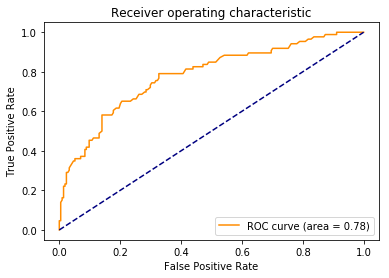

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=seed)
Rf_model = RandomForestClassifier(n_jobs=2,n_estimators=500,criterion='entropy',random_state=9999)
Rf_model.fit(X_train,y_train)
ypred = Rf_model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, ypred[::,1])
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

ROC curve can help you to choose a threshold that balances sensitivity and specificity in a way that makes sense for your particular context

# Q11. Calculate AUC(the percentage of the ROC plot that is underneath the curve) - optional

In [24]:
auc = roc_auc_score(y_test, ypred[::,1])
print('AUC: %.3f' % auc)

AUC: 0.781


### Bootstrapping ( Bonus)
##### Given a dataset of size n, a bootstrap sample is created by sampling n instances uniformly from the data (with/without replacement)
##### Create a model with each bootstrap sample and validate it with the test set
##### Final result is calculated by averaging the accuracy of models

In [25]:
# Number of iterations for bootstrapping
bootstrap_iteration = 10
accuracy = []

In [26]:
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

for i in range(bootstrap_iteration):
    X_, y_ = resample(X_train, y_train)
    Rf_model.fit(X_, y_)
    y_pred = Rf_model.predict(X_test)
    
    acc = accuracy_score(y_pred, y_test)
    accuracy.append(acc)

In [27]:
accuracy = np.array(accuracy)
print('Accuracy Score')
print('Avearge: ', accuracy.mean())
print('Standard deviation: ', accuracy.std())

Accuracy Score
Avearge:  0.7699999999999999
Standard deviation:  0.011155467020454333
